In [18]:
import os
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh

from mltau.tools.general import reinitialize_p4

In [7]:
datasets = {
    "model": "/home/laurits/0412_increased_stats/",
    "enreg": "/home/laurits/enreg/",
    "reco": "/home/laurits/mltaureco/"
}

samples = ["z", "zh", "qq"]

In [8]:
all_data = {}
for dataset, sample_dir in datasets.items():
    all_data[dataset] = {}
    for sample in samples:
        mm_path = os.path.join(sample_dir, f"{sample}_test.parquet")
        if os.path.exists(mm_path):
            all_data[dataset][sample] = ak.from_parquet(mm_path)

In [9]:
all_data

{'model': {'z': <Array [{reco_jet_p4: {...}, ...}, ..., {...}] type='356361 * {reco_jet_p4:...'>,
  'qq': <Array [{reco_jet_p4: {...}, ...}, ..., {...}] type='2358388 * {reco_jet_p4...'>},
 'enreg': {'z': <Array [{reco_cand_p4s: [...], ...}, ...] type='870843 * {reco_cand_p4s: va...'>,
  'zh': <Array [{reco_cand_p4s: [...], ...}, ...] type='1068606 * {reco_cand_p4s: v...'>,
  'qq': <Array [{reco_cand_p4s: [{...}], ...}, ...] type='6366715 * {reco_cand_p4s:...'>},
 'reco': {'z': <Array [{reco_cand_p4s: [{...}], ...}, ...] type='460382 * {reco_cand_p4s: ...'>,
  'zh': <Array [{reco_cand_p4s: [...], ...}, ...] type='521977 * {reco_cand_p4s: va...'>,
  'qq': <Array [{reco_cand_p4s: [...], ...}, ...] type='949958 * {reco_cand_p4s: va...'>}}

In [13]:

def to_bh(data, bins, cumulative=False):
    h1 = bh.Histogram(bh.axis.Variable(bins))
    h1.fill(data)
    if cumulative:
        h1[:] = np.sum(h1.values()) - np.cumsum(h1)
    return h1

In [14]:
def plot_histo(model_features, reco_features, enreg_features, bins, xlabel):
    fig, ax = plt.subplots()
    hep.histplot(
        to_bh(model_features, bins=bins),
        ax=ax,
        density=True,
        label="model",
        yerr=None,
    )
    hep.histplot(
        to_bh(reco_features, bins=bins),
        ax=ax,
        density=True,
        label="reco",
        yerr=None,
    )
    hep.histplot(
        to_bh(enreg_features, bins=bins),
        ax=ax,
        density=True,
        label="enreg",
        yerr=None,
    )
    plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel("Normalized count")

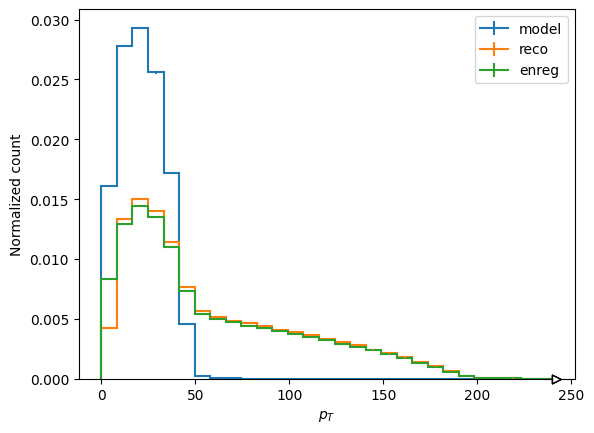

In [22]:
bins = np.linspace(0, 240, 30)
sample = "z"
model_features = reinitialize_p4(all_data["model"][sample].reco_jet_p4).pt
reco_features = reinitialize_p4(all_data["reco"][sample].reco_jet_p4s).pt
enreg_features = reinitialize_p4(all_data["enreg"][sample].reco_jet_p4s).pt
plot_histo(model_features, reco_features, enreg_features, bins=bins, xlabel=r"$p_T$")

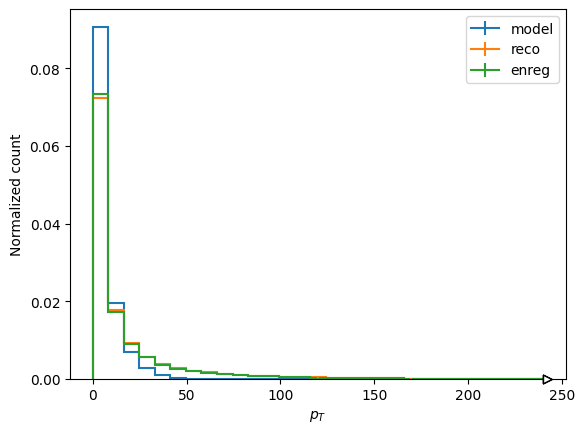

In [24]:
bins = np.linspace(0, 240, 30)
sample = "z"
model_features = ak.flatten(reinitialize_p4(all_data["model"][sample].reco_cand_p4s).pt)
reco_features = ak.flatten(reinitialize_p4(all_data["reco"][sample].reco_cand_p4s).pt)
enreg_features = ak.flatten(reinitialize_p4(all_data["enreg"][sample].reco_cand_p4s).pt)
plot_histo(model_features, reco_features, enreg_features, bins=bins, xlabel=r"$p_T$")

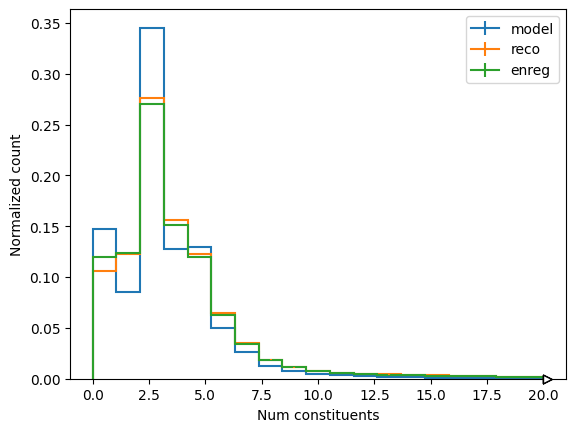

In [27]:
bins = np.linspace(0, 20, 20)
sample = "z"
model_features = ak.num(reinitialize_p4(all_data["model"][sample].reco_cand_p4s).pt)
reco_features = ak.num(reinitialize_p4(all_data["reco"][sample].reco_cand_p4s).pt)
enreg_features = ak.num(reinitialize_p4(all_data["enreg"][sample].reco_cand_p4s).pt)
plot_histo(model_features, reco_features, enreg_features, bins=bins, xlabel="Num constituents")

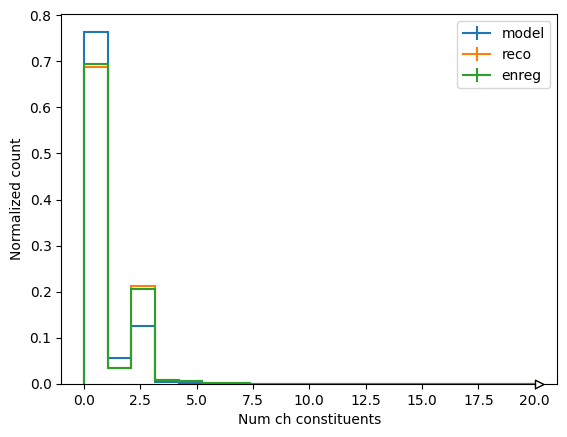

In [29]:
bins = np.linspace(0, 20, 20)
sample = "z"
model_features = ak.sum(np.abs(all_data["model"][sample].reco_cand_charges) == 1, axis=-1)
reco_features = ak.sum(np.abs(all_data["reco"][sample].reco_cand_charge) == 1, axis=-1)
enreg_features = ak.sum(np.abs(all_data["enreg"][sample].reco_cand_charge) == 1, axis=-1)

plot_histo(model_features, reco_features, enreg_features, bins=bins, xlabel="Num ch constituents")

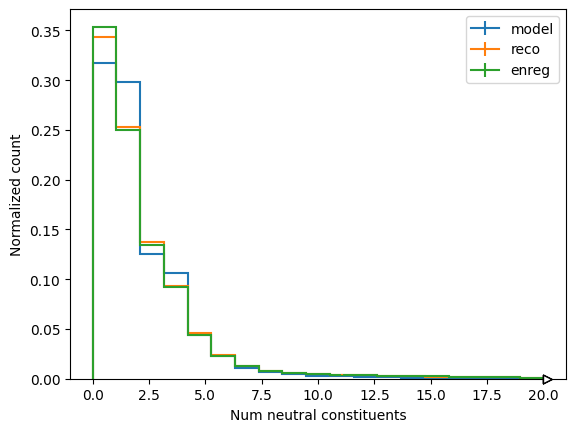

In [30]:
bins = np.linspace(0, 20, 20)
sample = "z"
model_features = ak.sum(np.abs(all_data["model"][sample].reco_cand_charges) == 0, axis=-1)
reco_features = ak.sum(np.abs(all_data["reco"][sample].reco_cand_charge) == 0, axis=-1)
enreg_features = ak.sum(np.abs(all_data["enreg"][sample].reco_cand_charge) == 0, axis=-1)

plot_histo(model_features, reco_features, enreg_features, bins=bins, xlabel="Num neutral constituents")

In [10]:
all_data["model"]["z"].fields

['reco_jet_p4',
 'reco_cand_p4s',
 'reco_cand_charges',
 'reco_cand_pdgs',
 'reco_cand_dz',
 'reco_cand_dz_error',
 'reco_cand_dxy',
 'reco_cand_dxy_error',
 'gen_jet_p4',
 'gen_jet_tau_decaymode',
 'gen_jet_tau_charge',
 'gen_jet_tau_p4',
 'cls_weight']

In [11]:
all_data["enreg"]["z"].fields

['reco_cand_p4s',
 'reco_cand_charge',
 'reco_cand_pdg',
 'reco_jet_p4s',
 'reco_cand_dxy',
 'reco_cand_dz',
 'reco_cand_dxy_err',
 'reco_cand_dz_err',
 'gen_jet_p4s',
 'gen_jet_tau_decaymode',
 'gen_jet_tau_p4s']

In [12]:
all_data["reco"]["z"].fields

['reco_cand_p4s',
 'reco_cand_charge',
 'reco_cand_pdg',
 'reco_jet_p4s',
 'reco_cand_dxy',
 'reco_cand_dz',
 'reco_cand_dxy_err',
 'reco_cand_dz_err',
 'gen_jet_p4s',
 'gen_jet_tau_decaymode',
 'gen_jet_tau_p4s']